In [7]:
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [2]:
import sys
sys.path.append(str(Path("../src").resolve()))
from c9_snrnaseq.io_utils import PROJECT_ROOT, load_and_annotate_sheet, save_checkpoint, _stage_header, _log
from c9_snrnaseq.qc_low_quality_cell import (
    compute_qc_metrics,
    detect_low_quality_cells,
    remove_low_quality_cells,
    freeze_raw_counts,
)
from c9_snrnaseq.ambient_rna import (
    estimate_ambient_rna,
    remove_ambient_rna,
)
from c9_snrnaseq.doublets_removal import (
    detect_doublets,
    remove_doublets,
)

from c9_snrnaseq.expression_preprocessing import (
    normalize_counts,
    log_transform,
    select_hvgs,
    scale_expression
)

from c9_snrnaseq.dimensionality_reduction import (
    run_pca,
    build_neighbor_graph,
    run_umap
)

from c9_snrnaseq.annotation import (
    run_leiden_clustering,
    find_cluster_markers
)

from c9_snrnaseq.pipeline import (
    process_one_sample
)

In [3]:
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
PSEUDOBULK_DIR = RESULTS_DIR / "pseudobulk"
PSEUDOBULK_EXC_DIR = RESULTS_DIR / "pseudobulk_exc_focus"
DE_BROAD_DIR = RESULTS_DIR / "de_pseudobulk_broad"
DE_EXC_DIR = RESULTS_DIR / "de_pseudobulk_exc_focus"

for d in [
    FIGURES_DIR,
    TABLES_DIR,
    PSEUDOBULK_DIR,
    PSEUDOBULK_EXC_DIR,
    DE_BROAD_DIR,
    DE_EXC_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

In [8]:
FIGURE_DPI = 300

def save_scanpy_figure(fig, filename):
    out = FIGURES_DIR / filename
    fig.savefig(out, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved figure: {out}")


def plot_obsm_2d_by_obs(
    adata,
    obsm_key,
    color_cols,
    axis_labels,
    title_prefix,
    filename,
    point_size=4,
    alpha=0.75,
):
    embedding = adata.obsm[obsm_key]
    plot_df = pd.DataFrame(
        embedding[:, :2],
        index=adata.obs_names,
        columns=axis_labels,
    ).join(adata.obs[color_cols])

    fig, axes = plt.subplots(1, len(color_cols), figsize=(6 * len(color_cols), 5))

    if len(color_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, color_cols):
        values = plot_df[col].astype(str)
        categories = sorted(values.unique())
        palette = dict(zip(categories, sns.color_palette("tab20", n_colors=len(categories))))

        for category in categories:
            sub = plot_df[values == category]
            ax.scatter(
                sub[axis_labels[0]],
                sub[axis_labels[1]],
                s=point_size,
                alpha=alpha,
                linewidth=0,
                rasterized=True,
                color=palette[category],
                label=category,
            )

        ax.set_title(f"{title_prefix}: {col}")
        ax.set_xlabel(axis_labels[0])
        ax.set_ylabel(axis_labels[1])

        if len(categories) <= 25:
            ax.legend(
                title=col,
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                markerscale=3,
                fontsize=8,
            )

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved figure: {FIGURES_DIR / filename}")
    plt.show()


def save_cluster_composition(adata, cluster_col, batch_col, filename):
    table = pd.crosstab(adata.obs[cluster_col], adata.obs[batch_col])
    out = TABLES_DIR / filename
    table.to_csv(out)
    print(f"Saved table: {out}")
    display(table)
    return table


def save_pc_mean_summary(adata, obsm_key, pc_prefix, filename_prefix):
    pc_df = pd.DataFrame(
        adata.obsm[obsm_key][:, :2],
        index=adata.obs_names,
        columns=[f"{pc_prefix}1", f"{pc_prefix}2"],
    ).join(adata.obs[["sample", "condition"]])

    by_sample = pc_df.groupby("sample")[[f"{pc_prefix}1", f"{pc_prefix}2"]].mean().sort_index()
    by_condition = pc_df.groupby("condition")[[f"{pc_prefix}1", f"{pc_prefix}2"]].mean().sort_index()

    by_sample.to_csv(TABLES_DIR / f"{filename_prefix}_mean_pc_by_sample.csv")
    by_condition.to_csv(TABLES_DIR / f"{filename_prefix}_mean_pc_by_condition.csv")

    print("Mean PC coordinates by sample")
    display(by_sample)

    print("Mean PC coordinates by condition")
    display(by_condition)

    return by_sample, by_condition


def compute_batch_asw(adata, obsm_key, batch_col="sample"):
    embedding = adata.obsm[obsm_key]
    labels = adata.obs[batch_col].astype(str).values

    raw_asw = silhouette_score(embedding, labels, metric="euclidean")
    batch_mixing_asw = 1 - abs(raw_asw)

    return {
        "obsm_key": obsm_key,
        "batch_col": batch_col,
        "raw_batch_asw": raw_asw,
        "batch_mixing_asw_1_minus_abs_asw": batch_mixing_asw,
    }


def compute_ilisi(adata, obsm_key, batch_col="sample", n_neighbors=30):
    embedding = adata.obsm[obsm_key]
    labels = adata.obs[batch_col].astype(str).values

    n_neighbors_eff = min(n_neighbors + 1, embedding.shape[0])
    nn = NearestNeighbors(n_neighbors=n_neighbors_eff, metric="euclidean")
    nn.fit(embedding)
    _, indices = nn.kneighbors(embedding)

    # Drop self-neighbour.
    indices = indices[:, 1:]

    ilisi_values = []
    for neighbours in indices:
        neighbour_labels = labels[neighbours]
        proportions = pd.Series(neighbour_labels).value_counts(normalize=True).values
        ilisi_values.append(1 / np.sum(proportions ** 2))

    ilisi_values = np.asarray(ilisi_values)

    return {
        "obsm_key": obsm_key,
        "batch_col": batch_col,
        "n_neighbors": n_neighbors,
        "ilisi_mean": float(np.mean(ilisi_values)),
        "ilisi_median": float(np.median(ilisi_values)),
        "ilisi_min": float(np.min(ilisi_values)),
        "ilisi_max": float(np.max(ilisi_values)),
    }


In [4]:
def process_all_samples_truncated(
    sample_sheet: str | Path = "config/samples.csv",
    processed_dir: str | Path = "data/processed/per_sample",
    merged_output_path: str | Path = "data/processed/merged/merged_after_clustering.h5ad",
    verbose: bool = True,
) -> dict:

    sample_sheet = Path(sample_sheet)
    if not sample_sheet.is_absolute():
        sample_sheet = PROJECT_ROOT / sample_sheet

    processed_dir = Path(processed_dir)
    if not processed_dir.is_absolute():
        processed_dir = PROJECT_ROOT / processed_dir

    merged_output_path = Path(merged_output_path)
    if not merged_output_path.is_absolute():
        merged_output_path = PROJECT_ROOT / merged_output_path

    sample_df = pd.read_csv(sample_sheet)
    cleaned_adatas = []
    cleaned_paths = []

    for _, sample_row in sample_df.iterrows():
        sample_id = str(sample_row["sample_id"])
        sample_dir = processed_dir / sample_id

        matches = sorted(sample_dir.glob("*_after_doublet_removal.h5ad"))
        if not matches:
            raise FileNotFoundError(
                f"No final cleaned checkpoint found for {sample_id} in {sample_dir}"
            )
        if len(matches) > 1:
            raise FileExistsError(
                f"Multiple final cleaned checkpoints found for {sample_id}: {matches}"
            )

        cleaned_path = matches[0]
        cleaned_paths.append(cleaned_path)
        cleaned_adatas.append(sc.read_h5ad(cleaned_path))

    adata_merged = sc.concat(
        cleaned_adatas,
        join="outer",
        label="concat_sample_id",
        keys=[adata.obs["sample"].iloc[0] for adata in cleaned_adatas],
        merge="same",
    )
    adata_merged.obs_names_make_unique()

    adata_merged = normalize_counts(adata_merged)
    adata_merged = log_transform(adata_merged)
    adata_merged = select_hvgs(adata_merged)
    adata_merged = scale_expression(adata_merged)
    adata_merged = run_pca(adata_merged)
    adata_merged = build_neighbor_graph(adata_merged)
    adata_merged = run_umap(adata_merged)
    adata_merged = run_leiden_clustering(adata_merged)
    adata_merged = find_cluster_markers(adata_merged)

    merged_output_path.parent.mkdir(parents=True, exist_ok=True)
    adata_merged.write_h5ad(merged_output_path)

    return {
        "sample_table": sample_df,
        "cleaned_paths": cleaned_paths,
        "adata_merged": adata_merged,
        "merged_output_path": merged_output_path,
    }

In [5]:
result = process_all_samples_truncated(
    sample_sheet="config/samples.csv",
    processed_dir="data/processed/per_sample",
    merged_output_path="data/processed/merged/merged_after_clustering.h5ad",
    verbose=True,
)

/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Normalization complete.
Input layer used: raw_counts
Output stored in: adata.layers['normalized_counts']
Target sum per cell: 10000.0
Log transformation complete.
Input layer used: normalized_counts
Output stored in: adata.layers['log1p_normalized_counts']
HVG selection complete.
Input layer used: log1p_normalized_counts
Number of HVGs selected: 2000



/opt/anaconda3/envs/c9_multiomics/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Expression scaling complete.
Input layer used: log1p_normalized_counts
Using HVGs only: True
Number of genes retained: 2000
Scaled matrix stored in adata_scaled.X
PCA complete.
Number of PCs computed: 50
PCA embedding stored in: adata.obsm['X_pca']


/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Neighbour graph complete.
n_neighbors used: 15
n_pcs used: 30
Graph stored in: adata.obsp['distances'], adata.obsp['connectivities']
UMAP complete.
UMAP coordinates stored in: adata.obsm['X_umap']


/Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/src/c9_snrnaseq/annotation.py:30: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


Leiden clustering complete.
Resolution used: 0.6
Cluster labels stored in: adata.obs['leiden']
Number of clusters detected: 20
Cluster marker detection complete.
Grouping column used: adata.obs['leiden']
Statistical method: wilcoxon
Results stored in: adata.uns['rank_genes_groups']


Saved figure: /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/figures/08_batch_pre_harmony_umap_leiden_sample_condition.png


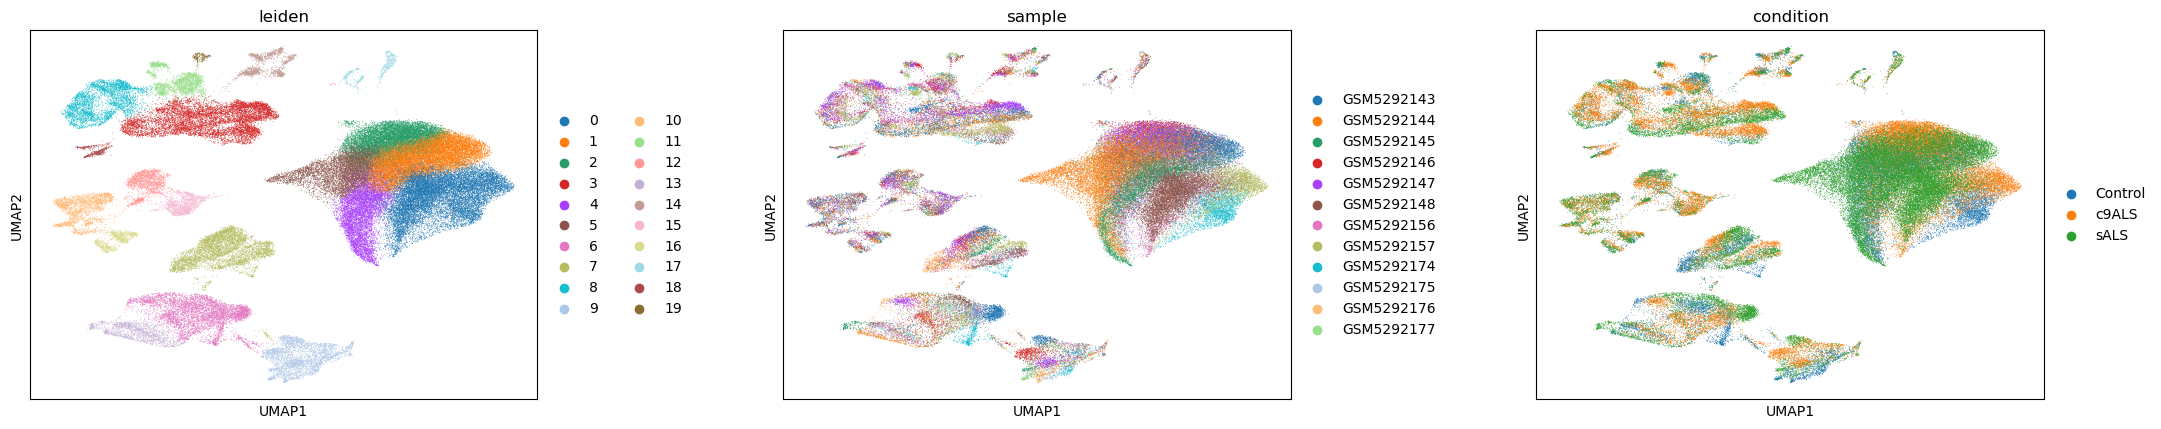

In [9]:
adata_merged = result["adata_merged"]

fig = sc.pl.umap(
    adata_merged,
    color=["leiden", "sample", "condition"],
    wspace=0.35,
    show=False,
    return_fig=True,
)

save_scanpy_figure(
    fig,
    "08_batch_pre_harmony_umap_leiden_sample_condition.png",
)
plt.show()


Saved figure: /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/figures/08_batch_pre_harmony_pca_leiden_sample_condition.png


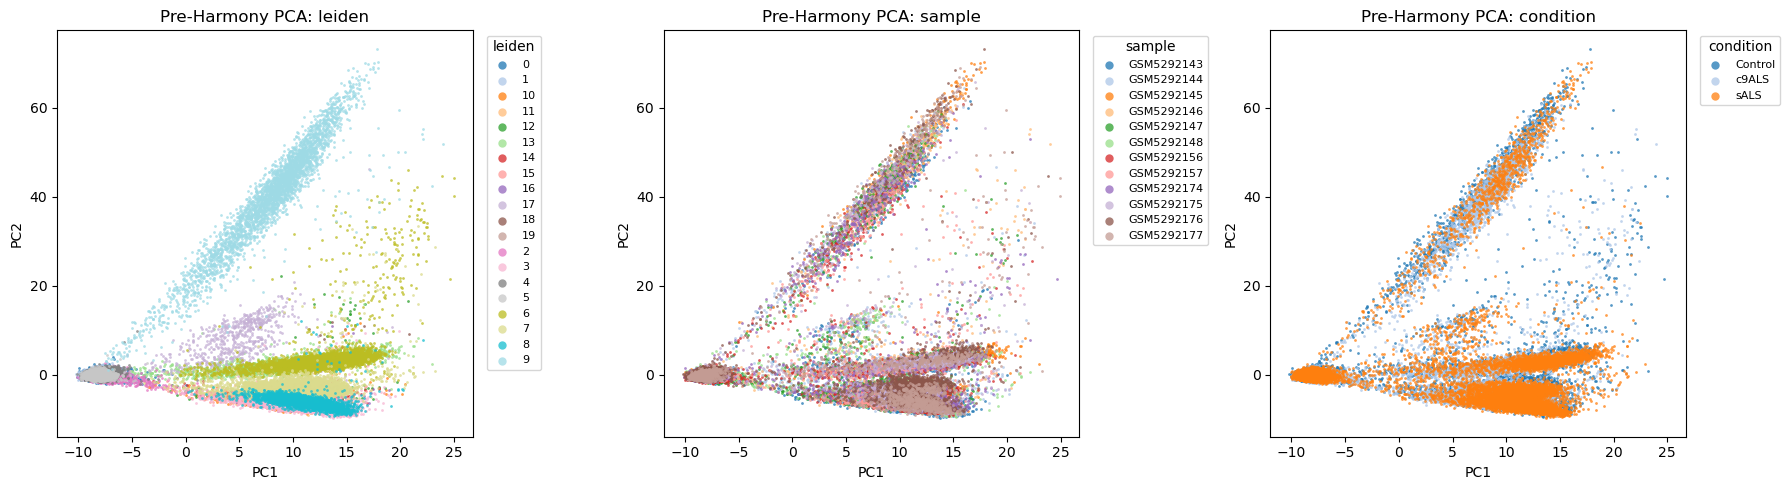

In [10]:
plot_obsm_2d_by_obs(
    adata=adata_merged,
    obsm_key="X_pca",
    color_cols=["leiden", "sample", "condition"],
    axis_labels=["PC1", "PC2"],
    title_prefix="Pre-Harmony PCA",
    filename="08_batch_pre_harmony_pca_leiden_sample_condition.png",
)


In [11]:
pre_cluster_by_sample = save_cluster_composition(
    adata=adata_merged,
    cluster_col="leiden",
    batch_col="sample",
    filename="08_batch_pre_harmony_cluster_composition_by_sample.csv",
)

pre_pc_by_sample, pre_pc_by_condition = save_pc_mean_summary(
    adata=adata_merged,
    obsm_key="X_pca",
    pc_prefix="PC",
    filename_prefix="08_batch_pre_harmony",
)

pre_batch_asw = compute_batch_asw(
    adata=adata_merged,
    obsm_key="X_pca",
    batch_col="sample",
)

pre_ilisi = compute_ilisi(
    adata=adata_merged,
    obsm_key="X_pca",
    batch_col="sample",
    n_neighbors=30,
)

pre_metric_summary = pd.DataFrame([pre_batch_asw | pre_ilisi])
pre_metric_summary.to_csv(
    TABLES_DIR / "08_batch_pre_harmony_batch_metrics.csv",
    index=False,
)

display(pre_metric_summary)


Saved table: /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/tables/08_batch_pre_harmony_cluster_composition_by_sample.csv


sample,GSM5292143,GSM5292144,GSM5292145,GSM5292146,GSM5292147,GSM5292148,GSM5292156,GSM5292157,GSM5292174,GSM5292175,GSM5292176,GSM5292177
leiden,,,,,,,,,,,,
0,6,23,9,15,40,5878,2325,2640,2910,14,9,9
1,2757,1903,2571,864,1078,381,326,144,93,1604,1547,605
2,529,1077,28,2496,2845,311,247,320,114,827,494,197
3,1548,862,36,889,1449,331,596,1376,309,211,136,124
4,249,1376,1600,474,525,107,235,49,40,1207,1024,467
5,21,4444,92,106,148,237,24,4,202,129,490,201
6,939,391,96,491,354,492,464,566,665,571,138,344
7,472,575,258,413,500,557,324,358,338,404,779,211
8,311,231,23,515,913,164,434,536,170,185,153,134


Mean PC coordinates by sample


/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_41596/2969643788.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_sample = pc_df.groupby("sample")[[f"{pc_prefix}1", f"{pc_prefix}2"]].mean().sort_index()
/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_41596/2969643788.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_condition = pc_df.groupby("condition")[[f"{pc_prefix}1", f"{pc_prefix}2"]].mean().sort_index()


,PC1,PC2
sample,,
GSM5292143,3.236351,-0.920106
GSM5292144,-2.852826,-0.279270
GSM5292145,-4.601880,1.532426
GSM5292146,1.704081,0.874586
GSM5292147,1.794859,-0.916052
GSM5292148,-2.966520,-0.357729
GSM5292156,0.979135,-0.891010
GSM5292157,2.717004,-1.225534
GSM5292174,-0.032914,1.575938


Mean PC coordinates by condition


,PC1,PC2
condition,,
Control,-0.039499,1.107114
c9ALS,1.833269,-0.507075
sALS,-1.662796,-0.190778


,obsm_key,batch_col,raw_batch_asw,batch_mixing_asw_1_minus_abs_asw,n_neighbors,ilisi_mean,ilisi_median,ilisi_min,ilisi_max
0,X_pca,sample,-0.088844,0.911156,30,2.656082,2.284264,1.0,10.227273


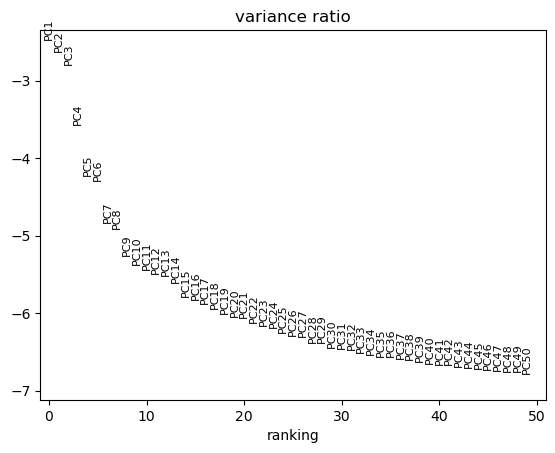

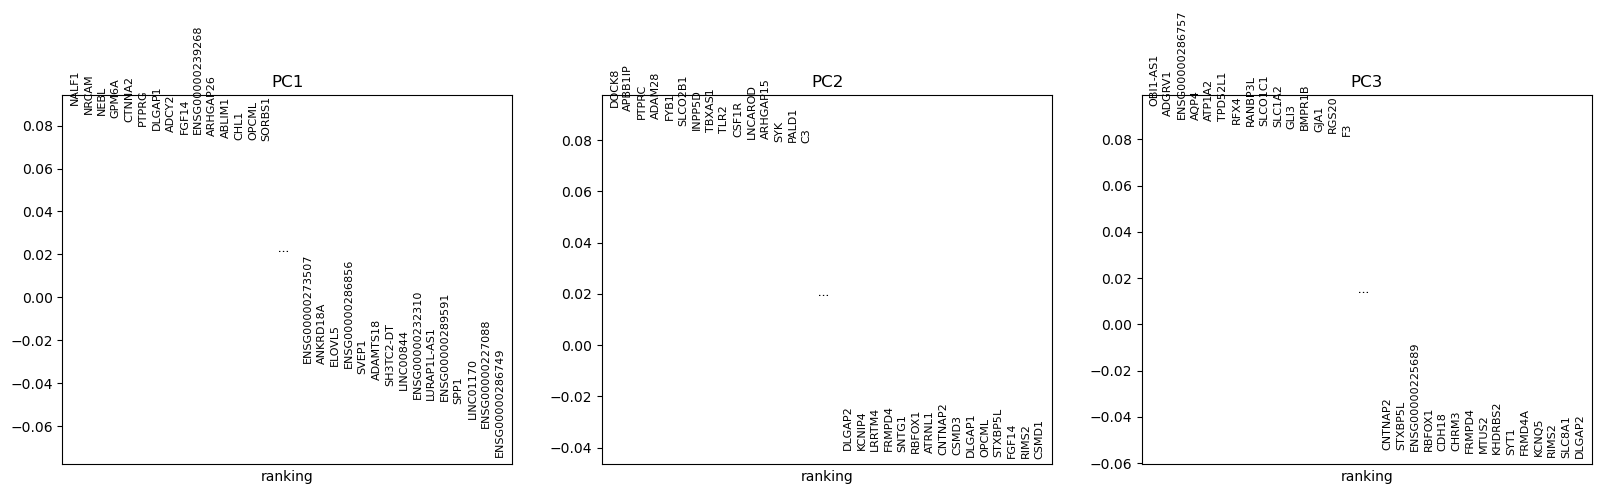

In [9]:
sc.pl.pca_variance_ratio(adata_merged, log=True, n_pcs=50)
sc.pl.pca_loadings(adata_merged, components=[1, 2, 3], include_lowest=True)

In [10]:
pca_df = pd.DataFrame(
    adata_merged.obsm["X_pca"][:, :10],
    index=adata_merged.obs_names,
    columns=[f"PC{i}" for i in range(1, 11)]
)

pca_df = pd.concat([pca_df, adata_merged.obs[["sample", "condition"]]], axis=1)

# mean PC1 by sample
print(pca_df.groupby("sample")["PC1"].mean().sort_values())

# mean PC1 by condition
print(pca_df.groupby("condition")["PC1"].mean().sort_values())

sample
GSM5292145   -4.601880
GSM5292148   -2.966520
GSM5292144   -2.852826
GSM5292175   -0.648749
GSM5292176   -0.247156
GSM5292174   -0.032914
GSM5292156    0.979135
GSM5292177    1.649666
GSM5292146    1.704081
GSM5292147    1.794859
GSM5292157    2.717004
GSM5292143    3.236351
Name: PC1, dtype: float32
condition
sALS      -1.662796
Control   -0.039499
c9ALS      1.833269
Name: PC1, dtype: float32


/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_46296/1363487467.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pca_df.groupby("sample")["PC1"].mean().sort_values())
/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_46296/1363487467.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pca_df.groupby("condition")["PC1"].mean().sort_values())


## Harmony Integration And Broad Cell-Class Annotation

2026-04-22 18:35:44,318 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-04-22 18:35:44,324 - harmonypy - INFO -   Parameters:
2026-04-22 18:35:44,325 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-22 18:35:44,325 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-22 18:35:44,325 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-22 18:35:44,326 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-22 18:35:44,326 - harmonypy - INFO -     nclust: 100
2026-04-22 18:35:44,326 - harmonypy - INFO -     block_size: 0.05
2026-04-22 18:35:44,328 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-04-22 18:35:44,329 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-04-22 18:35:44,329 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-22 18:35:44,330 - harmonypy - INFO -     verbose: True
2026-04-22 18:35:44,330 - harmonypy - INFO -     random_state: 0
2026-04-22 18:35:44,330 - harmonypy - INFO -   Data: 50 

Saved figure: /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/figures/08_batch_post_harmony_umap_leiden_sample_condition.png


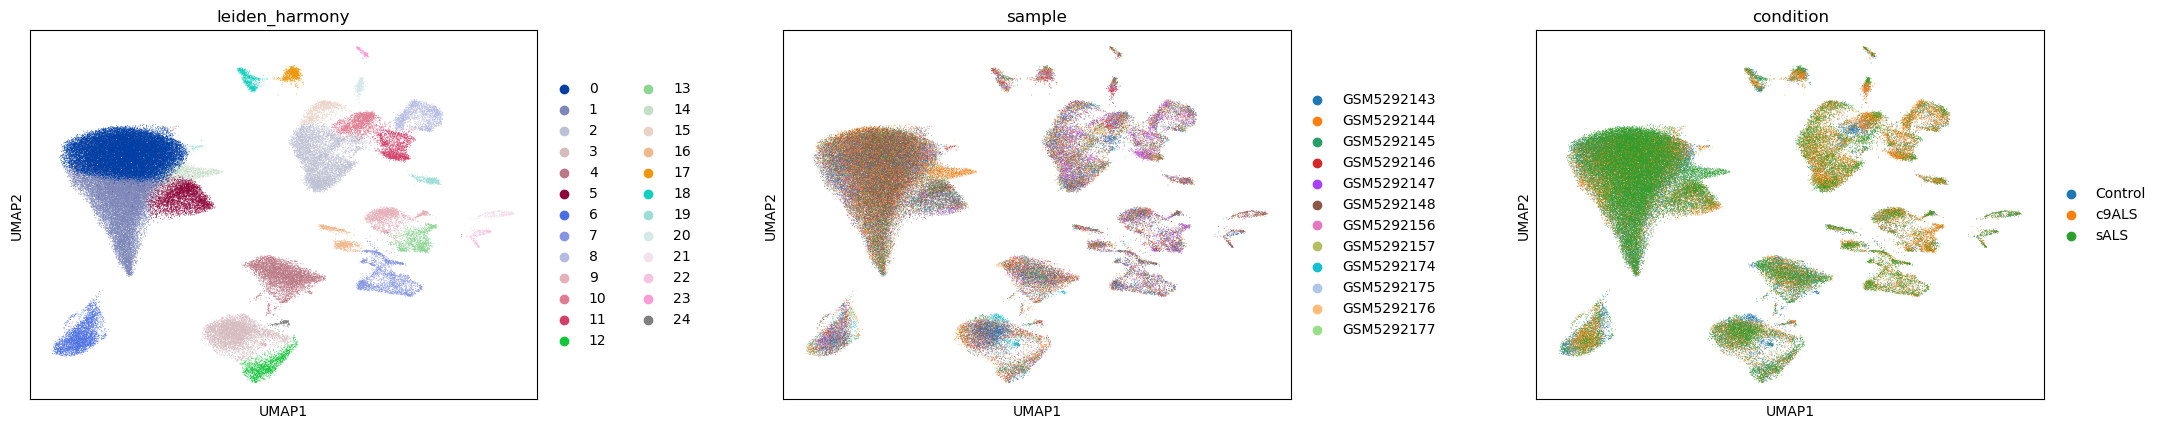

In [12]:
import harmonypy as hm

adata_hm = adata_merged.copy()

# Harmony on existing PCA.
X = adata_hm.obsm["X_pca"].astype("float64")
ho = hm.run_harmony(X, adata_hm.obs, vars_use="sample")

Z = ho.Z_corr
if Z.shape != X.shape:
    Z = Z.T

adata_hm.obsm["X_pca_harmony"] = Z

# Build graph and embedding from Harmony PCs.
sc.pp.neighbors(adata_hm, use_rep="X_pca_harmony")
sc.tl.umap(adata_hm, random_state=0)
sc.tl.leiden(adata_hm, resolution=0.6, key_added="leiden_harmony")

fig = sc.pl.umap(
    adata_hm,
    color=["leiden_harmony", "sample", "condition"],
    wspace=0.35,
    show=False,
    return_fig=True,
)

save_scanpy_figure(
    fig,
    "08_batch_post_harmony_umap_leiden_sample_condition.png",
)
plt.show()

In [13]:
hm_ckpt = PROJECT_ROOT / "data/processed/merged/adata_hm_after_harmony.h5ad"
hm_ckpt.parent.mkdir(parents=True, exist_ok=True)

adata_hm.write_h5ad(hm_ckpt)

print(f"Saved Harmony-integrated object to: {hm_ckpt}")
print(adata_hm.shape)
print("Has X_pca_harmony:", "X_pca_harmony" in adata_hm.obsm)
print("Has leiden_harmony:", "leiden_harmony" in adata_hm.obs.columns)

Saved Harmony-integrated object to: /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/data/processed/merged/adata_hm_after_harmony.h5ad
(89819, 2000)
Has X_pca_harmony: True
Has leiden_harmony: True


Saved figure: /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/figures/08_batch_post_harmony_pca_leiden_sample_condition.png


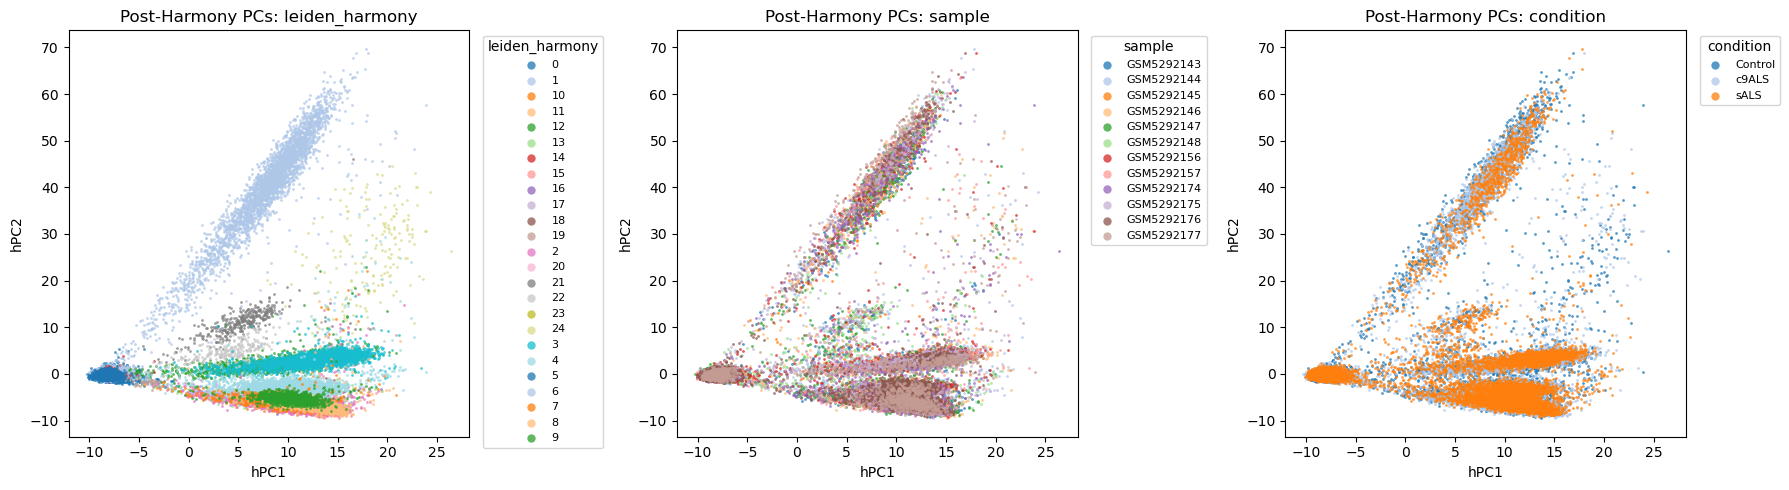

In [14]:
plot_obsm_2d_by_obs(
    adata=adata_hm,
    obsm_key="X_pca_harmony",
    color_cols=["leiden_harmony", "sample", "condition"],
    axis_labels=["hPC1", "hPC2"],
    title_prefix="Post-Harmony PCs",
    filename="08_batch_post_harmony_pca_leiden_sample_condition.png",
)

In [15]:
post_cluster_by_sample = save_cluster_composition(
    adata=adata_hm,
    cluster_col="leiden_harmony",
    batch_col="sample",
    filename="08_batch_post_harmony_cluster_composition_by_sample.csv",
)

post_pc_by_sample, post_pc_by_condition = save_pc_mean_summary(
    adata=adata_hm,
    obsm_key="X_pca_harmony",
    pc_prefix="hPC",
    filename_prefix="08_batch_post_harmony",
)

post_batch_asw = compute_batch_asw(
    adata=adata_hm,
    obsm_key="X_pca_harmony",
    batch_col="sample",
)

post_ilisi = compute_ilisi(
    adata=adata_hm,
    obsm_key="X_pca_harmony",
    batch_col="sample",
    n_neighbors=30,
)

post_metric_summary = pd.DataFrame([post_batch_asw | post_ilisi])
post_metric_summary.to_csv(
    TABLES_DIR / "08_batch_post_harmony_batch_metrics.csv",
    index=False,
)

display(post_metric_summary)


Saved table: /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/tables/08_batch_post_harmony_cluster_composition_by_sample.csv


sample,GSM5292143,GSM5292144,GSM5292145,GSM5292146,GSM5292147,GSM5292148,GSM5292156,GSM5292157,GSM5292174,GSM5292175,GSM5292176,GSM5292177
leiden_harmony,,,,,,,,,,,,
0,2494,4789,1975,2485,2673,3817,1656,1717,1892,2098,2139,878
1,922,2809,1561,1047,1241,2481,1247,1049,943,1350,1322,537
2,1284,748,23,721,1314,293,543,1213,283,191,136,98
3,922,389,95,451,342,484,459,523,626,557,141,308
4,475,576,258,414,500,558,328,360,338,404,780,211
5,129,282,756,373,699,601,240,375,327,318,85,54
6,331,249,164,551,438,118,206,271,381,237,198,208
7,550,293,24,208,447,184,184,319,126,58,83,23
8,197,113,11,282,462,64,158,299,82,87,90,79


Mean PC coordinates by sample


/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_41596/2969643788.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_sample = pc_df.groupby("sample")[[f"{pc_prefix}1", f"{pc_prefix}2"]].mean().sort_index()
/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_41596/2969643788.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_condition = pc_df.groupby("condition")[[f"{pc_prefix}1", f"{pc_prefix}2"]].mean().sort_index()


,hPC1,hPC2
sample,,
GSM5292143,3.112246,-0.594168
GSM5292144,-2.753684,-0.193604
GSM5292145,-4.890429,0.839430
GSM5292146,2.167233,0.411731
GSM5292147,2.213783,-0.888466
GSM5292148,-3.087737,-0.243686
GSM5292156,1.139777,-0.278477
GSM5292157,3.089867,-1.057254
GSM5292174,0.035033,1.742429


Mean PC coordinates by condition


,hPC1,hPC2
condition,,
Control,-0.072949,0.928693
c9ALS,2.205023,-0.468019
sALS,-1.732786,-0.153082


,obsm_key,batch_col,raw_batch_asw,batch_mixing_asw_1_minus_abs_asw,n_neighbors,ilisi_mean,ilisi_median,ilisi_min,ilisi_max
0,X_pca_harmony,sample,-0.160172,0.839828,30,5.516368,5.555556,1.0,11.25
